In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
state_codes = pd.read_excel("state_codes.xlsx")
state_codes.columns = ['state_code', 'state_name']
state_codes['state_name'] = state_codes['state_name'].str.strip()

In [85]:
ev = pd.read_excel("States_Electric_Vehicle_Registrations_2018.xlsx", sheet_name="Condensed")
ev = ev.iloc[1:, 1:3]                       # drop junk first col + title row
ev.columns = ['state_name', 'ev_registrations']
ev = ev.dropna(subset=['state_name']).reset_index(drop=True)
ev['state_name'] = ev['state_name'].str.strip()
ev['ev_registrations'] = pd.to_numeric(ev['ev_registrations'], errors='coerce')
ev = ev.dropna(subset=['ev_registrations']).reset_index(drop=True)   # drops leftover header row

In [86]:
raw = pd.read_excel("States_All_Vehicle_Registrations_2018.xlsx", sheet_name="MV1", header=None)
veh = raw.iloc[12:63, [0, 15]].copy()       # state name col + "TOTAL ALL MOTOR VEHICLES" col
veh.columns = ['state_name', 'total_vehicles']
veh['state_name'] = (veh['state_name']
                      .str.replace(r'\(\d+\)', '', regex=True)   # remove footnote markers like (2)
                      .str.strip())
veh['total_vehicles'] = pd.to_numeric(veh['total_vehicles'], errors='coerce')
veh = veh.dropna(subset=['state_name'])

In [87]:
energy = pd.read_excel("States_Annual_Energy_Generation_Sources_1990_2019.xlsx", header=1)
energy.columns = ['year', 'state_code', 'producer_type', 'energy_source', 'generation_mwh']
energy['state_code'] = energy['state_code'].str.strip()
energy = energy[~energy['state_code'].isin(['', 'US-TOTAL', 'US-Total'])]   # drop junk/national rows
energy['state_code'] = energy['state_code'].str.upper()

In [88]:
state_codes.head()

,state_code,state_name
0,AK,Alaska
1,AL,Alabama
2,AR,Arkansas
3,AZ,Arizona
4,CA,California


In [89]:
ev.head()

,state_name,ev_registrations
0,Alabama,1450.0
1,Alaska,530.0
2,Arizona,15000.0
3,Arkansas,520.0
4,California,256800.0


In [90]:
veh.head()

,state_name,total_vehicles
12,Alabama,5.300199e+06
13,Alaska,8.036836e+05
14,Arizona,5.806313e+06
15,Arkansas,2.817145e+06
16,California,3.102233e+07


In [91]:
energy.head()

,year,state_code,producer_type,energy_source,generation_mwh
0,1990,AK,Total Electric Power Industry,Total,5599506.0
1,1990,AK,Total Electric Power Industry,Coal,510573.0
2,1990,AK,Total Electric Power Industry,Hydroelectric Conventional,974521.0
3,1990,AK,Total Electric Power Industry,Natural Gas,3466261.0
4,1990,AK,Total Electric Power Industry,Petroleum,497116.0


In [92]:
energy_total_industry = energy[energy['producer_type'] == 'Total Electric Power Industry'].copy()
energy_total_industry = energy_total_industry.merge(state_codes, on='state_code', how='left')

In [93]:
ev.to_csv("clean_ev_registrations.csv", index=False)
veh.to_csv("clean_total_vehicles.csv", index=False)
energy_total_industry.to_csv("clean_energy_generation.csv", index=False)
state_codes.to_csv("clean_state_codes.csv", index=False)


In [94]:
print(ev.shape)
print(veh.shape)
print(energy_total_industry.shape)

(51, 2)
(51, 2)
(14360, 6)


In [95]:
for d in (ev, veh, energy_total_industry):
    d['state_name'] = d['state_name'].str.strip().str.title()


In [96]:
energy_2018 = energy_total_industry[energy_total_industry['year'] == 2018].copy()

RENEWABLE_SOURCES = [
    'Hydroelectric Conventional', 'Wind', 'Solar Thermal and Photovoltaic',
    'Geothermal', 'Wood and Wood Derived Fuels', 'Other Biomass'
]

total_gen = (energy_2018[energy_2018['energy_source'] == 'Total']
             .groupby('state_name')['generation_mwh'].sum()
             .reset_index().rename(columns={'generation_mwh': 'total_generation_mwh'}))

renewable_gen = (energy_2018[energy_2018['energy_source'].isin(RENEWABLE_SOURCES)]
                  .groupby('state_name')['generation_mwh'].sum()
                  .reset_index().rename(columns={'generation_mwh': 'renewable_generation_mwh'}))

energy_summary = total_gen.merge(renewable_gen, on='state_name', how='left')
energy_summary['renewable_generation_mwh'] = energy_summary['renewable_generation_mwh'].fillna(0)
energy_summary['renewable_share_pct'] = (energy_summary['renewable_generation_mwh']
                                          / energy_summary['total_generation_mwh'] * 100)

In [97]:
veh['state_name'] = veh['state_name'].replace({'Dist. Of Col.': 'District Of Columbia'})
master = ev.merge(veh, on='state_name', how='left')
master = master.merge(energy_summary, on='state_name', how='left')

In [98]:
master['ev_per_1000_vehicles'] = (master['ev_registrations'] / master['total_vehicles']) * 1000

print("Master shape:", master.shape)
print("Nulls per column:\n", master.isna().sum())

master.to_csv("master_2018.csv", index=False)


Master shape: (51, 7)
Nulls per column:
 state_name                  0
ev_registrations            0
total_vehicles              0
total_generation_mwh        0
renewable_generation_mwh    0
renewable_share_pct         0
ev_per_1000_vehicles        0
dtype: int64


In [99]:
master = pd.read_csv("master_2018.csv")


In [100]:
cols = ['ev_per_1000_vehicles', 'renewable_share_pct', 'total_generation_mwh']
corr_matrix = master[cols].corr()
print("Correlation matrix:\n", corr_matrix)


Correlation matrix:
                       ev_per_1000_vehicles  renewable_share_pct  \
ev_per_1000_vehicles              1.000000             0.241633   
renewable_share_pct               0.241633             1.000000   
total_generation_mwh              0.103840            -0.270968   

                      total_generation_mwh  
ev_per_1000_vehicles              0.103840  
renewable_share_pct              -0.270968  
total_generation_mwh              1.000000  


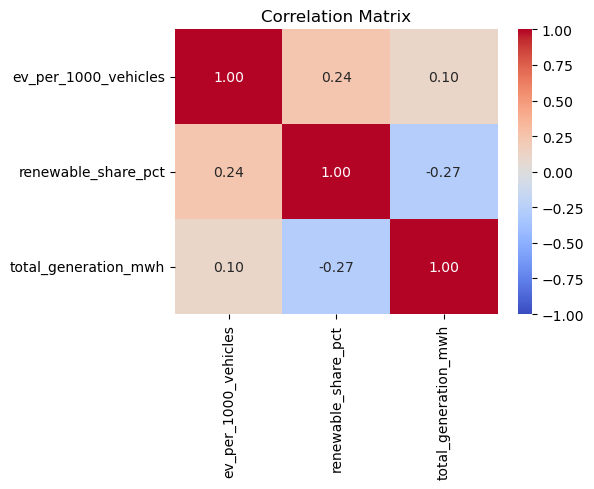

In [101]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [102]:
from scipy import stats
r, p_value = stats.pearsonr(master['renewable_share_pct'], master['ev_per_1000_vehicles'])
print(f"\nPearson correlation (r): {r:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Statistically significant at 95% confidence: {p_value < 0.05}")



Pearson correlation (r): 0.242
P-value: 0.0876
Statistically significant at 95% confidence: False


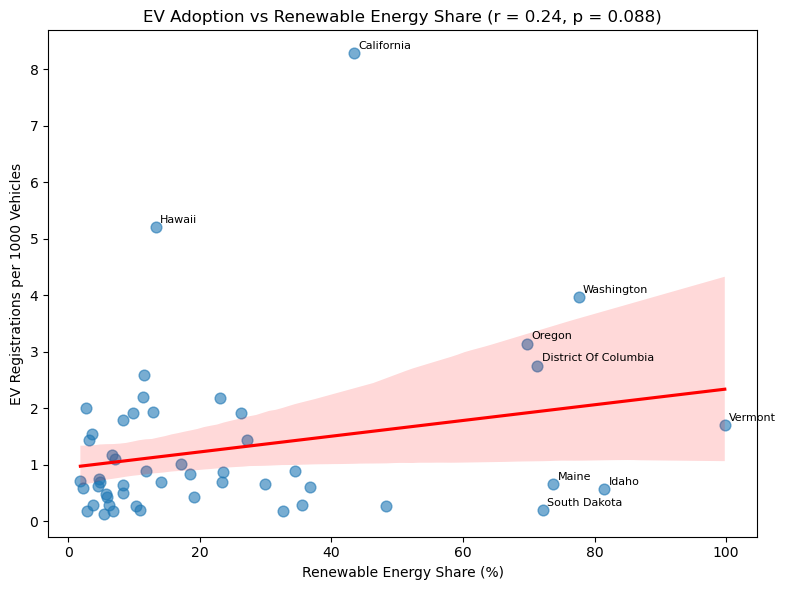

In [103]:
plt.figure(figsize=(8, 6))
sns.regplot(data=master, x='renewable_share_pct', y='ev_per_1000_vehicles',
            scatter_kws={'alpha': 0.6, 's': 60}, line_kws={'color': 'red'})
plt.title(f'EV Adoption vs Renewable Energy Share (r = {r:.2f}, p = {p_value:.3f})')
plt.xlabel('Renewable Energy Share (%)')
plt.ylabel('EV Registrations per 1000 Vehicles')

for _, row in master.iterrows():
    if row['ev_per_1000_vehicles'] > 3 or row['renewable_share_pct'] > 70:
        plt.annotate(row['state_name'], (row['renewable_share_pct'], row['ev_per_1000_vehicles']),
                     fontsize=8, xytext=(3, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

In [104]:
def renewable_share_for_year(yr):
    sub = energy_total_industry[energy_total_industry['year'] == yr]
    tot = sub[sub['energy_source'] == 'Total'].groupby('state_name')['generation_mwh'].sum()
    ren = sub[sub['energy_source'].isin(RENEWABLE_SOURCES)].groupby('state_name')['generation_mwh'].sum()
    return (ren / tot * 100).rename(f'renewable_pct_{yr}')

share_1990 = renewable_share_for_year(1990)
share_2018 = renewable_share_for_year(2018)

growth = pd.concat([share_1990, share_2018], axis=1).fillna(0)
growth['growth_pct_points'] = growth['renewable_pct_2018'] - growth['renewable_pct_1990']
growth = growth.sort_values('growth_pct_points', ascending=False)

print("\nTop 10 states: biggest renewable share growth, 1990 -> 2018")
print(growth.head(10))


Top 10 states: biggest renewable share growth, 1990 -> 2018
                      renewable_pct_1990  renewable_pct_2018  \
state_name                                                     
District Of Columbia            0.000000           71.297475   
Vermont                        28.659664           99.787417   
Kansas                          0.038845           36.753281   
Iowa                            2.972697           35.470709   
Oklahoma                        6.375090           34.519487   
Maine                          47.034845           73.747241   
North Dakota                    6.339167           32.650476   
New Mexico                      0.761837           23.333663   
Minnesota                       4.102915           23.495301   
Colorado                        4.451439           23.105618   

                      growth_pct_points  
state_name                               
District Of Columbia          71.297475  
Vermont                       71.127753  
Ka

In [105]:
master['state_name'] = master['state_name'].str.strip().str.title()
state_codes['state_name'] = state_codes['state_name'].str.strip().str.title()

master = master.merge(state_codes, on='state_name', how='left')
print("Missing codes:", master[master['state_code'].isna()]['state_name'].tolist())

Missing codes: []


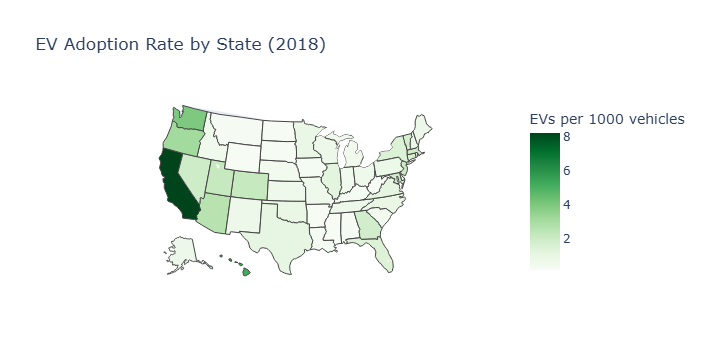

In [106]:
import plotly.express as px

fig1 = px.choropleth(
    master,
    locations='state_code',
    locationmode='USA-states',
    color='ev_per_1000_vehicles',
    scope='usa',
    color_continuous_scale='Greens',
    labels={'ev_per_1000_vehicles': 'EVs per 1000 vehicles'},
    title='EV Adoption Rate by State (2018)'
)
fig1.show()


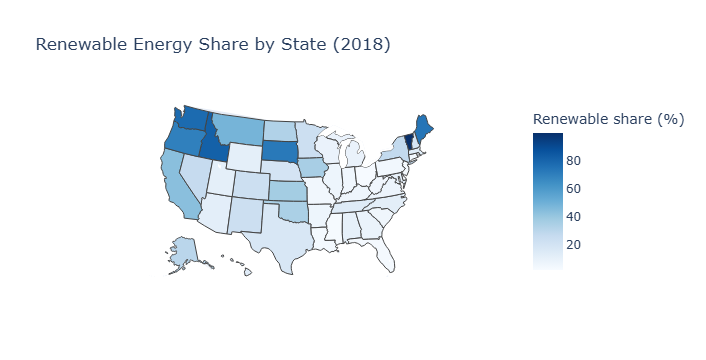

In [107]:
fig2 = px.choropleth(
    master,
    locations='state_code',
    locationmode='USA-states',
    color='renewable_share_pct',
    scope='usa',
    color_continuous_scale='Blues',
    labels={'renewable_share_pct': 'Renewable share (%)'},
    title='Renewable Energy Share by State (2018)'
)
fig2.show()